# Explore here

In [17]:
%pip install -r ../requirements.txt

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [18]:
# Your code here
import pandas as pd

df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=932&path=url_spam.csv')

df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,True
1,https://www.hvper.com/,True
2,https://briefingday.com/m/v4n3i4f3,True
3,https://briefingday.com/n/20200618/m#commentform,False
4,https://briefingday.com/fan,True


In [19]:
df['is_spam'] = df['is_spam'].apply(lambda x: 1 if x == True else 0).astype(int)

df.head()

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,1
1,https://www.hvper.com/,1
2,https://briefingday.com/m/v4n3i4f3,1
3,https://briefingday.com/n/20200618/m#commentform,0
4,https://briefingday.com/fan,1


In [20]:
print(f'Spam {len(df.loc[df['is_spam'] == 1])}')
print(f'No Spam {len(df.loc[df['is_spam'] == 0])}')

Spam 696
No Spam 2303


In [21]:
df.drop_duplicates(inplace=True)

In [22]:
print(f'Spam {len(df.loc[df['is_spam'] == 1])}')
print(f'No Spam {len(df.loc[df['is_spam'] == 0])}')

Spam 244
No Spam 2125


In [23]:
df.reset_index(inplace=True, drop=True)
df

,url,is_spam
0,https://briefingday.us8.list-manage.com/unsubs...,1
1,https://www.hvper.com/,1
2,https://briefingday.com/m/v4n3i4f3,1
3,https://briefingday.com/n/20200618/m#commentform,0
4,https://briefingday.com/fan,1
...,...,...
2364,https://www.theverge.com/2020/6/29/21306889/di...,0
2365,https://www.smartcitiesworld.net/news/news/dee...,0
2366,https://techcrunch.com/2019/07/04/an-optimisti...,0
2367,https://www.technologyreview.com/2019/12/20/13...,0


In [24]:
%pip install regex

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [25]:
import regex as re

def preprocesar_texto(texto):
    ####remover caracteres que no sean una letra o un / o un espacio en blanco
    texto = re.sub(r'[^\p{L}/\s.]', '', texto)

    ####Reemplazar // por /
    texto = texto.replace('//','/')

    ####Separa por / y por . a la vez
    return re.split(r'[/.]' , texto)

texto_prueba = 'https://briefingday.com/fan'
print(preprocesar_texto(texto_prueba))



['https', 'briefingday', 'com', 'fan']


In [26]:
df['url'] = df['url'].apply(preprocesar_texto)
df.head()

,url,is_spam
0,"[https, briefingday, us, listmanage, com, unsu...",1
1,"[https, www, hvper, com, ]",1
2,"[https, briefingday, com, m, vnif]",1
3,"[https, briefingday, com, n, mcommentform]",0
4,"[https, briefingday, com, fan]",1


In [27]:
%pip install WordCloud

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 550.7/550.7 kB 3.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


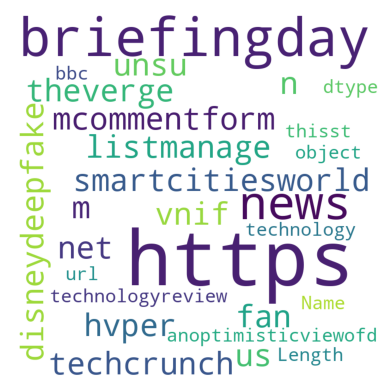

In [30]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

nube = WordCloud(width=800, height=800, background_color='white', max_words= 1000, min_font_size=20, random_state=42)\
    .generate(str(df['url']))

plt.imshow(nube)
plt.axis('off')
plt.show()

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

lista_tokenizable = df['url']
lista_tokenizable = [" ".join(tokens) for tokens in lista_tokenizable]

print(lista_tokenizable)


['https briefingday us listmanage com unsubscribe', 'https www hvper com ', 'https briefingday com m vnif', 'https briefingday com n mcommentform', 'https briefingday com fan', 'https www brookings edu interactives reopeningamericaandtheworld ', 'https www reuters com investigates specialreport healthcoronavirusbritainpub ', 'https www theatlantic com magazine archive  supermarketsareamiracle ', 'https www vox com   johnboltonbookexcerptstrumpukrainechina', 'https www theguardian com travel jun endoftourismcoronaviruspandemictravelindustry', 'https www bbc com future article whatifallvirusesdisappeared', 'https narratively com thequarantinedhippiestrappedinajungleparadise ', 'https ourworldindata org grapher dailycovidcasesdayaverage', 'https www spikedonline com  ahealthysocietydoesnotdestroyitsmonuments ', 'https www nytimes com interactive  business economy howcontainershipsarebuilt html', 'https aeon co essays nostalgiaistherocketfuelthatpowershopeandchange', 'https www youtube com

In [33]:
vectorizador = TfidfVectorizer(max_features=10000, max_df=0.8, min_df=5)
X = vectorizador.fit_transform(lista_tokenizable).toarray()
y = df['is_spam']

X[:1]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.51974885, 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.  

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

X_train

array([[0.        , 0.        , 0.        , ..., 0.        , 0.21119963,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.13753315,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.        , 0.19364653,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 1.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ]], shape=(1895, 189))